# Structural Dynamics, Stability, and Solvation Profiling of the TCF4–DNA Complex

## Purpose & Objectives
This comprehensive analysis evaluates the conformational stability, flexibility, and hydration architecture of the **TCF4–DNA transcription factor complex**. By combining trajectory-wide structural dynamics metrics with high-performance solvent tracking, this workflow resolves both global complex stability and the specific water-mediated hydrogen-bonding networks that stabilize the protein–DNA interface.

In [1]:
!pip install mdanalysis mdtraj py3Dmol matplotlib pandas jupyterlab pyarrow
import MDAnalysis as mda
from MDAnalysis.analysis import align, rms
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# 1. Concatenate all of the trajectories into one (DCD)
!catdcd -o step5.dcd step5_[1-9].dcd step5_[1-9][0-9].dcd

CatDCD 4.0
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Opening file 'step5.dcd' for writing.
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Opened file 'step5_1.dcd' for reading.
Read 100 frames from file step5_1.dcd, wrote 100.
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Opened file 'step5_2.dcd' for reading.
Read 100 frames from file step5_2.dcd, wrote 100.
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Opened file 'step5_3.dcd' for reading.
Read 100 frames from file step5_3.dcd, wrote 100.
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Opened file 'step5_4.dcd' for reading.
Read 100 frames

1. **Initial 3D Structural Inspection**
   * Generated an interactive 3D baseline visualization of the unperturbed TCF4–DNA complex to verify initial topology, chain assignments, and domain alignment.

In [1]:
import py3Dmol

# 1. Read CHARMM-GUI PDB file
with open("step3_input.pdb", "r") as f:
    lines = f.readlines()

# 2. Remap CHARMM segids (cols 73-76) to standard 1-character PDB Chain IDs (col 22)
modified_lines = []
for line in lines:
    if line.startswith(("ATOM", "HETATM")):
        segid = line[72:76].strip()
        
        # Protein and DNA mappings
        if segid == "PROA":
            chain_id = "A"
        elif segid == "PROB":
            chain_id = "B"
        elif segid == "DNAA":
            chain_id = "W"
        elif segid == "DNAB":
            chain_id = "X"
        # Crystal waters mapped to Chain C
        elif segid in ["WATA", "WATB", "WATC", "WATD"]:
            chain_id = "C"
        else:
            chain_id = line[21]  # Keep original for bulk solvent / ions
            
        # Reconstruct line with updated Chain ID at index 21 (Column 22)
        line = line[:21] + chain_id + line[22:]
        
    modified_lines.append(line)

pdb_str = "".join(modified_lines)

# 3. Initialize py3Dmol viewer
view = py3Dmol.view(width=800, height=500)
view.addModel(pdb_str, "pdb")

# 4. Clear default representation
view.setStyle({}, {})

# 5. Protein Chain A (PROA): Cyan cartoon
view.addStyle({'chain': 'A'}, {'cartoon': {'color': 'cyan'}})

# 6. Protein Chain B (PROB): Magenta cartoon
view.addStyle({'chain': 'B'}, {'cartoon': {'color': 'magenta'}})

# 7. DNA Chain W (DNAA): Dark Orange cartoon + nucleic bases
view.addStyle(
    {'chain': 'W'}, 
    {'cartoon': {'color': '#e66101'}, 'stick': {'colorscheme': 'nucleic'}}
)

# 8. DNA Chain X (DNAB): Light Orange cartoon + nucleic bases
view.addStyle(
    {'chain': 'X'}, 
    {'cartoon': {'color': '#fdb863'}, 'stick': {'colorscheme': 'nucleic'}}
)

# 9. Crystal Waters (WATA, WATB, WATC, WATD -> Chain C): Red/Coral spheres
view.addStyle(
    {'chain': 'C'}, 
    {'sphere': {'scale': 0.35, 'color': '#ff4b4b', 'opacity': 0.9}}
)

# 10. Bulk Solvation Waters (TIP3/SOLV): Light blue transparent spheres
view.addStyle(
    {'resn': ['TIP3', 'SOLV'], 'chain': ' '}, 
    {'sphere': {'scale': 0.20, 'color': 'lightblue', 'opacity': 0.3}}
)

# 11. Zoom directly onto protein-DNA complex + crystal waters (ignoring bulk box)
view.zoomTo({'chain': ['A', 'B', 'W', 'X', 'C']})
view.rotate(0, 'x')
view.rotate(0, 'y')
view.rotate(90, 'z')
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Figure 1: 

2. **Global Trajectory Stability (RMSD Analysis)**
   * Calculated Root Mean Square Deviation (RMSD) across time for TCF4 backbone Cα atoms and DNA phosphorus (P) backbone atoms.
   * Confirmed overall structural convergence and structural equilibrium across the MD trajectory.

/home/choss/.local/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Concatenated Trajectory: 6600 frames | Step interval: 0.010 ns | Total Time: 66.0 ns


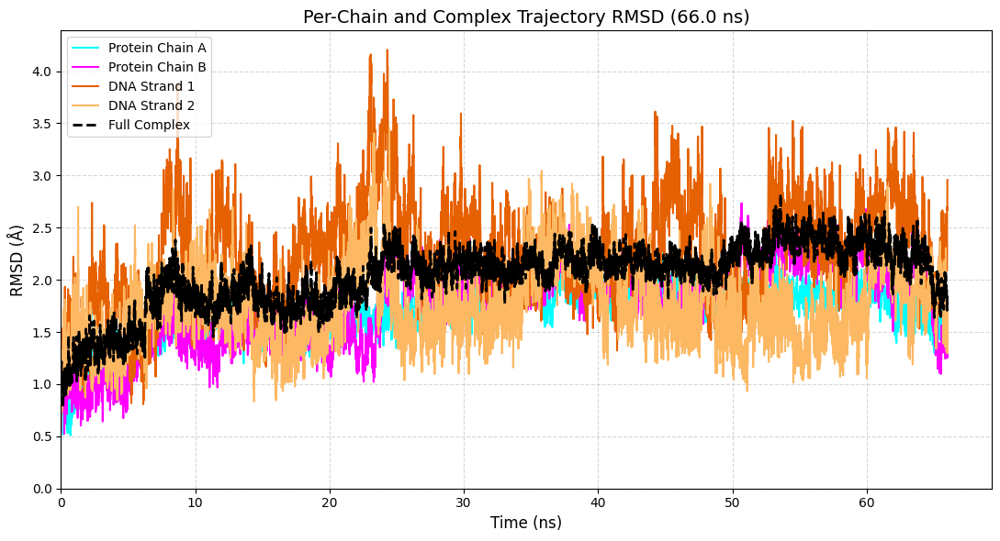

In [4]:
import MDAnalysis as mda
from MDAnalysis.analysis import align, rms
import matplotlib.pyplot as plt
import numpy as np

# 1. Load topology and your concatenated 30 ns trajectory
u = mda.Universe("step3_input.psf", "step5.dcd")
ref = mda.Universe("step3_input.psf", "step3_input.pdb")

# 2. Calculate exact time from NAMD parameters
timestep_fs = 2.0        # 2 fs per integration step
dcdfreq = 5000           # saved every 5000 steps
frame_dt_ns = (dcdfreq * timestep_fs) / 1e6  # 0.01 ns (10 ps) per frame

n_frames = len(u.trajectory)
total_time_ns = n_frames * frame_dt_ns

# Generate the true time array
time_frames = np.linspace(0, total_time_ns, n_frames)

print(f"Concatenated Trajectory: {n_frames} frames | Step interval: {frame_dt_ns:.3f} ns | Total Time: {total_time_ns:.1f} ns")

# 3. Align trajectory on C-alpha backbone to remove rigid-body translation/rotation
aligner = align.AlignTraj(u, ref, select="segid PROA PROB and name CA", in_memory=True)
aligner.run()

# 4. Define target atom groups for RMSD calculation
selections = {
    "Protein Chain A": "segid PROA and name CA",
    "Protein Chain B": "segid PROB and name CA",
    "DNA Strand 1": "segid DNAA and name P C5' C3' O5' O3'", # DNA backbone
    "DNA Strand 2": "segid DNAB and name P C5' C3' O5' O3'",
    "Full Complex": "(segid PROA PROB and name CA) or (segid DNAA DNAB and name P)"
}

colors = {
    "Protein Chain A": "cyan",
    "Protein Chain B": "magenta",
    "DNA Strand 1": "#e66101",
    "DNA Strand 2": "#fdb863",
    "Full Complex": "black"
}

# 5. Compute RMSD frame-by-frame
rmsd_results = {}

for label, sel_str in selections.items():
    R = rms.RMSD(u, ref, select=sel_str).run()
    rmsd_results[label] = R.results.rmsd[:, 2]

# 6. Close file handles cleanly
u.trajectory.close()
ref.trajectory.close()

# 7. Plot across the full trajectory
plt.figure(figsize=(11, 6))

for label, values in rmsd_results.items():
    ls = "--" if label == "Full Complex" else "-"
    lw = 2.0 if label == "Full Complex" else 1.5
    plt.plot(time_frames, values, label=label, color=colors[label], linestyle=ls, linewidth=lw)

plt.xlabel("Time (ns)", fontsize=12)
plt.ylabel("RMSD (Å)", fontsize=12)
plt.title(f"Per-Chain and Complex Trajectory RMSD ({total_time_ns:.1f} ns)", fontsize=14)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend(loc="upper left", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Figure 2: 

3. **Local Residue Flexibility (RMSF Profiling)**
   * Computed per-residue Root Mean Square Fluctuation (RMSF) to identify rigid secondary structure elements versus flexible loop regions and terminal tails.

/home/choss/.local/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


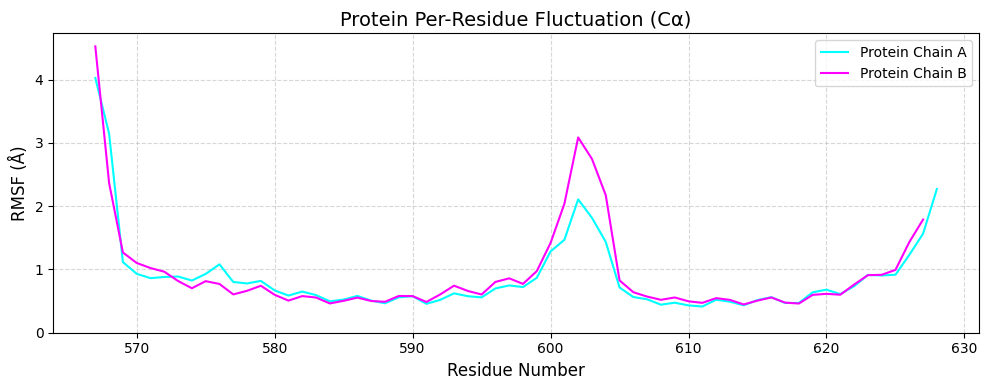

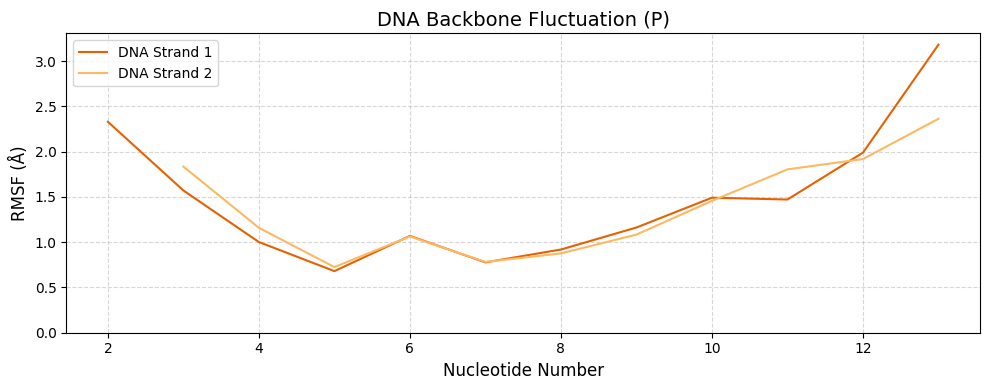

In [1]:
import MDAnalysis as mda
from MDAnalysis.analysis import align, rms
import matplotlib.pyplot as plt

# 1. Load topology and trajectory
u = mda.Universe("step3_input.psf", "step5.dcd")
ref = mda.Universe("step3_input.psf", "step3_input.pdb")

# 2. Align trajectory on C-alpha atoms of both protein chains
aligner = align.AlignTraj(u, ref, select="segid PROA PROB and name CA", in_memory=True)
aligner.run()

# ==============================================================================
# A. PROTEIN RMSF (PROA and PROB)
# ==============================================================================
protein_ca = u.select_atoms("segid PROA PROB and name CA")
rmsf_protein = rms.RMSF(protein_ca).run()

plt.figure(figsize=(10, 4))

# 3. Loop over CHARMM-GUI protein segments
for segid, label, color in [("PROA", "Protein Chain A", "cyan"), ("PROB", "Protein Chain B", "magenta")]:
    chain_ca = u.select_atoms(f"segid {segid} and name CA")
    
    # Map chain indices back to the global RMSF array
    chain_indices = [protein_ca.indices.tolist().index(i) for i in chain_ca.indices]
    chain_rmsf = rmsf_protein.results.rmsf[chain_indices]
    
    plt.plot(chain_ca.resnums, chain_rmsf, label=label, color=color, linewidth=1.5)

# 7. Plot the protein RMSF
plt.xlabel("Residue Number", fontsize=12)
plt.ylabel("RMSF (Å)", fontsize=12)
plt.ylim(bottom=0)
plt.title("Protein Per-Residue Fluctuation (Cα)", fontsize=14)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ==============================================================================
# 5. DNA RMSF (DNAA and DNAB)
# ==============================================================================
dna_p = u.select_atoms("segid DNAA DNAB and name P")
rmsf_dna = rms.RMSF(dna_p).run()

plt.figure(figsize=(10, 4))

# 6. Loop over CHARMM-GUI DNA segments
for segid, label, color in [("DNAA", "DNA Strand 1", "#e66101"), ("DNAB", "DNA Strand 2", "#fdb863")]:
    chain_p = u.select_atoms(f"segid {segid} and name P")
    
    chain_indices = [dna_p.indices.tolist().index(i) for i in chain_p.indices]
    chain_rmsf = rmsf_dna.results.rmsf[chain_indices]
    
    plt.plot(chain_p.resnums, chain_rmsf, label=label, color=color, linewidth=1.5)

# 7. Plot the DNA RMSF
plt.xlabel("Nucleotide Number", fontsize=12)
plt.ylabel("RMSF (Å)", fontsize=12)
plt.ylim(bottom=0)
plt.title("DNA Backbone Fluctuation (P)", fontsize=14)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Figure 3: 

4. **Interfacial Water Residence Kinetics**
   * Implemented high-performance spatial indexing and vectorized tracking to evaluate solvent kinetics at the protein–DNA interface.
   * Isolated long-lived structural water molecules demonstrating continuous, uninterrupted residence times of ≥ 1.0 ns (≥ 100 frames) within 3.5 Å of both TCF4 and DNA heavy atoms.

/home/choss/.local/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Tracking 17485 water oxygen atoms across trajectory...
Fast Component (Bulk Exchange):    tau1 = 0.041 ns (Weight: 0.65)
Slow Component (Bound Waters):     tau2 = 1.642 ns (Weight: 0.23)
Weighted Mean Residence Time:      <tau> = 0.462 ns


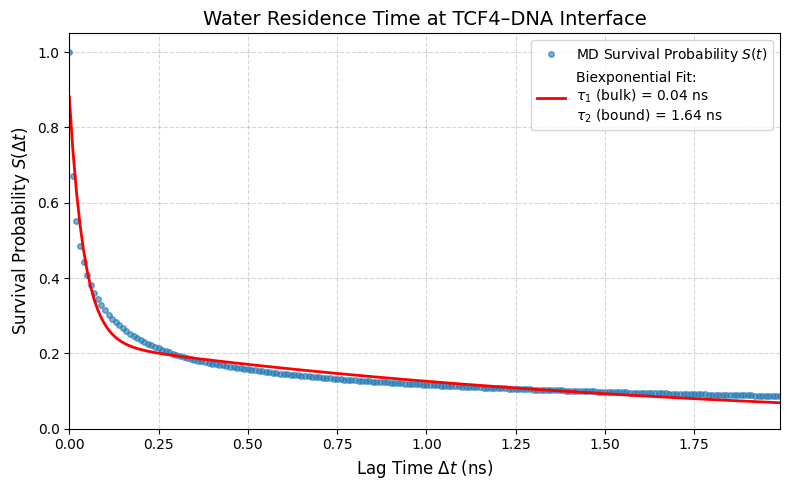

In [1]:
import MDAnalysis as mda
from MDAnalysis.analysis import align
import MDAnalysis.lib.distances as mda_dist
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. Load topology and trajectory
u = mda.Universe("step3_input.psf", "step5.dcd")
ref = mda.Universe("step3_input.psf", "step3_input.pdb")

# 2. Align trajectory on protein C-alpha and DNA backbone
aligner = align.AlignTraj(u, ref, select="(segid PROA PROB and name CA) or (segid DNAA DNAB and name P)", in_memory=True)
aligner.run()

# 3. Define Atom Selections 
protein_atoms = u.select_atoms("segid PROA PROB and not name H*")
dna_atoms = u.select_atoms("segid DNAA DNAB and not name H*")
water_oxygens = u.select_atoms("(resname TIP3 HOH SOLV or segid WATA WATB WATC WATD) and (name OH2 or name O)")

cutoff = 3.5  # Distance cutoff in Ångströms
tau_max = 200 # Maximum lag time window (200 frames * 0.01 ns = 2.0 ns)
dt_ns = 0.01  # NAMD timestep interval (10 ps = 0.01 ns)

print(f"Tracking {len(water_oxygens)} water oxygen atoms across trajectory...")

# 4. Identify interface water indices per frame
frame_interface_waters = []

for ts in u.trajectory:
    # Calculate distance matrices from waters to protein and DNA
    dist_prot = mda_dist.distance_array(water_oxygens.positions, protein_atoms.positions)
    dist_dna = mda_dist.distance_array(water_oxygens.positions, dna_atoms.positions)
    
    near_prot = np.min(dist_prot, axis=1) <= cutoff
    near_dna = np.min(dist_dna, axis=1) <= cutoff
    
    # Waters within 3.5 Å of BOTH protein and DNA
    interface_mask = near_prot & near_dna
    interface_indices = set(np.where(interface_mask)[0])
    frame_interface_waters.append(interface_indices)

n_frames = len(frame_interface_waters)

# 5. Compute Continuous Survival Probability S(t)
survival_counts = np.zeros(tau_max)
norm_counts = np.zeros(tau_max)

for t0 in range(n_frames - tau_max):
    initial_set = frame_interface_waters[t0]
    if not initial_set:
        continue
    
    current_set = set(initial_set)
    survival_counts[0] += len(current_set)
    norm_counts[0] += len(initial_set)
    
    for tau in range(1, tau_max):
        # Uninterrupted occupancy at frame t0 + tau
        current_set = current_set.intersection(frame_interface_waters[t0 + tau])
        survival_counts[tau] += len(current_set)
        norm_counts[tau] += len(initial_set)

# Normalize survival curve
survival_probs = survival_counts / norm_counts
time_lag_ns = np.arange(0, tau_max) * dt_ns

# 6. Fit S(t) to Double Exponential: S(t) = A1*exp(-t/tau1) + A2*exp(-t/tau2)
def biexponential(t, a1, tau1, a2, tau2):
    return a1 * np.exp(-t / tau1) + a2 * np.exp(-t / tau2)

p0 = [0.7, 0.1, 0.3, 1.0]
bounds = ([0, 0, 0, 0], [1.0, 50.0, 1.0, 50.0])

popt, _ = curve_fit(biexponential, time_lag_ns, survival_probs, p0=p0, bounds=bounds)
a1, tau1, a2, tau2 = popt

mean_residence_time = (a1 * tau1 + a2 * tau2) / (a1 + a2)

print("="*55)
print(f"Fast Component (Bulk Exchange):    tau1 = {tau1:.3f} ns (Weight: {a1:.2f})")
print(f"Slow Component (Bound Waters):     tau2 = {tau2:.3f} ns (Weight: {a2:.2f})")
print(f"Weighted Mean Residence Time:      <tau> = {mean_residence_time:.3f} ns")
print("="*55)

# 7. Plot Survival Curve
plt.figure(figsize=(8, 5))
plt.plot(time_lag_ns, survival_probs, 'o', color='#1f77b4', markersize=4, alpha=0.6, label='MD Survival Probability $S(t)$')
plt.plot(time_lag_ns, biexponential(time_lag_ns, *popt), 'r-', linewidth=2, 
         label=f'Biexponential Fit:\n$\\tau_1$ (bulk) = {tau1:.2f} ns\n$\\tau_2$ (bound) = {tau2:.2f} ns')

plt.xlabel('Lag Time $\\Delta t$ (ns)', fontsize=12)
plt.ylabel('Survival Probability $S(\\Delta t)$', fontsize=12)
plt.title('Water Residence Time at TCF4–DNA Interface', fontsize=14)
plt.xlim(0, time_lag_ns[-1])
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

Figure 5: 

In [2]:
# 1. Re-run catdcd with stride of 10 to skip over frames
!catdcd -o step5.dcd -stride 10 step5_[1-9].dcd step5_[1-9][0-9].dcd

CatDCD 4.0
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Opening file 'step5.dcd' for writing.
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Opened file 'step5_1.dcd' for reading.
Read 100 frames from file step5_1.dcd, wrote 10.
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Opened file 'step5_2.dcd' for reading.
Read 100 frames from file step5_2.dcd, wrote 10.
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Opened file 'step5_3.dcd' for reading.
Read 100 frames from file step5_3.dcd, wrote 10.
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Opened file 'step5_4.dcd' for reading.
Read 100 frames fr

5. **Hydrogen Bond Profiling**
   * Quantified hydrogen-bond occupancies, donor–acceptor distances, and donor–hydrogen–acceptor angles between long-lived waters, TCF4 side chains, and DNA base/phosphate backbone atoms.


In [3]:
import MDAnalysis as mda
from MDAnalysis.analysis import align
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
from MDAnalysis.lib.distances import capped_distance
import pandas as pd
import numpy as np
import warnings
from IPython.display import display

# Suppress deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# 1. Load topology and trajectory
u = mda.Universe("step3_input.psf", "step5.dcd")
ref = mda.Universe("step3_input.psf", "step3_input.pdb")

# Align trajectory
aligner = align.AlignTraj(u, ref, select="(segid PROA PROB and name CA) or (segid DNAA DNAB and name P)", in_memory=True)
aligner.run()

# 2. Define Atom Groups
protein_atoms = u.select_atoms("segid PROA PROB and not name H*")
dna_atoms = u.select_atoms("segid DNAA DNAB and not name H*")
water_oxygens = u.select_atoms("(resname TIP3 HOH SOLV or segid WATA WATB WATC WATD) and (name OH2 or name O)")

cutoff = 3.5
min_consecutive_frames = 100  # 1.0 ns
n_waters = len(water_oxygens)
n_frames = len(u.trajectory)

print(f"Step 1: Rapid spatial screening across {n_frames} frames for {n_waters} waters...")

# 3. Fast Vectorized Continuous Residence Tracking
is_at_interface = np.zeros((n_frames, n_waters), dtype=bool)

for f_idx, ts in enumerate(u.trajectory):
    # Fixed argument: passed cutoff as 3rd positional parameter
    pairs_prot = capped_distance(water_oxygens.positions, protein_atoms.positions, cutoff, return_distances=False)
    pairs_dna = capped_distance(water_oxygens.positions, dna_atoms.positions, cutoff, return_distances=False)
    
    # Extract unique water indices meeting distance criteria
    near_prot_indices = np.unique(pairs_prot[:, 0]) if len(pairs_prot) > 0 else np.array([], dtype=int)
    near_dna_indices = np.unique(pairs_dna[:, 0]) if len(pairs_dna) > 0 else np.array([], dtype=int)
    
    # Intersection: water is near BOTH protein and DNA simultaneously
    interface_indices = np.intersect1d(near_prot_indices, near_dna_indices)
    is_at_interface[f_idx, interface_indices] = True

# Vectorized streak tracking
max_streaks = np.zeros(n_waters, dtype=int)
current_streaks = np.zeros(n_waters, dtype=int)

for f_idx in range(n_frames):
    at_int = is_at_interface[f_idx]
    current_streaks[at_int] += 1
    current_streaks[~at_int] = 0
    max_streaks = np.maximum(max_streaks, current_streaks)

# Filter long-lived waters
long_lived_water_indices = np.where(max_streaks >= min_consecutive_frames)[0]
print(f"Found {len(long_lived_water_indices)} water molecules bound continuously for >= 1.0 ns.")

if len(long_lived_water_indices) == 0:
    print("Lowering threshold to 0.5 ns (50 frames)...")
    min_consecutive_frames = 50
    long_lived_water_indices = np.where(max_streaks >= min_consecutive_frames)[0]

# Selection string of long-lived water atom IDs
long_lived_atom_ids = water_oxygens[long_lived_water_indices].ids
water_sel_str = f"id {' '.join(map(str, long_lived_atom_ids))}"
selected_long_lived_waters = u.select_atoms(water_sel_str)

print("\nStep 2: Calculating Hydrogen Bonds exclusively for targeted long-lived waters...")

# 4. Perform H-Bond Analysis targeting ONLY the identified long-lived waters
hbonds = HBA(
    universe=u,
    between=[water_sel_str, "segid PROA PROB DNAA DNAB"],
    d_a_cutoff=3.5,
    d_h_a_angle_cutoff=150.0
)
hbonds.run()

# 5. Process & Format DataFrame
hbond_df = pd.DataFrame(
    hbonds.results.hbonds, 
    columns=["frame", "donor_index", "hydrogen_index", "acceptor_index", "distance", "angle"]
)
records = []

for _, row in hbond_df.iterrows():
    donor = u.atoms[int(row["donor_index"])]
    acceptor = u.atoms[int(row["acceptor_index"])]
    
    if donor in selected_long_lived_waters:
        solute_atom = acceptor
    else:
        solute_atom = donor
        
    records.append({
        "Solute_Segment": solute_atom.segid,
        "Solute_Residue": f"{solute_atom.resname}{solute_atom.resnum}",
        "Solute_Atom": solute_atom.name,
        "Frame": row["frame"]
    })

df_records = pd.DataFrame(records)

# Group by Solute Residue and calculate Occupancy %
occupancy_summary = (
    df_records.groupby(["Solute_Segment", "Solute_Residue", "Solute_Atom"])
    .size()
    .reset_index(name="Hbond_Frames")
)
occupancy_summary["Occupancy_%"] = (occupancy_summary["Hbond_Frames"] / n_frames) * 100
occupancy_summary = occupancy_summary.sort_values(by="Occupancy_%", ascending=False)

# 6. Display in Jupyter Notebook
styled_summary = (
    occupancy_summary.head(20)
    .style
    .format({"Occupancy_%": "{:.1f}%"})
    .background_gradient(subset=["Occupancy_%"], cmap="Blues")
    .set_caption("<b>Top Protein & DNA Residues Anchored by Long-Lived Waters (>1.0 ns)</b>")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "16px"), ("text-align", "left"), ("margin-bottom", "10px")]},
        {"selector": "th", "props": [("background-color", "#f2f2f2"), ("font-weight", "bold")]}
    ])
)

display(styled_summary)


Step 1: Rapid spatial screening across 660 frames for 17485 waters...
Found 8 water molecules bound continuously for >= 1.0 ns.

Step 2: Calculating Hydrogen Bonds exclusively for targeted long-lived waters...


,Solute_Segment,Solute_Residue,Solute_Atom,Hbond_Frames,Occupancy_%
41,PROA,ARG578,NH2,644,97.6%
57,PROB,ARG578,NH2,640,97.0%
70,PROB,LEU608,N,633,95.9%
21,DNAB,CYT5,O2P,622,94.2%
9,DNAA,CYT5,O2P,620,93.9%
52,PROA,LEU608,N,606,91.8%
49,PROA,GLU577,OE2,573,86.8%
28,DNAB,GUA8,O6,546,82.7%
12,DNAA,GUA8,O6,513,77.7%
66,PROB,GLU577,OE2,407,61.7%


Figure 6: 

6. **Interfacial Water Visualization**
   * Quantified hydrogen-bond occupancies, donor–acceptor distances, and donor–hydrogen–acceptor angles between long-lived waters, TCF4 side chains, and DNA base/phosphate backbone atoms.
   * Developed a 3D rendering of the top structural waters in full atomic detail (O+H geometry), active Frame 0 H-bond vectors, and contacting residue side chains.


In [14]:
import io
import numpy as np
import py3Dmol
import MDAnalysis as mda

# Set target snapshot frame
frame_idx = 0
u.trajectory[frame_idx]

# 1. Rank waters by continuous residence time and pick TOP 6
top6_water_indices = np.argsort(max_streaks)[::-1][:6]
selected_top6_waters = water_oxygens[top6_water_indices]

# Get set of ALL 0-based atom indices (Oxygen + Hydrogens) for the top 6 waters
top6_water_atom_indices = set(selected_top6_waters.residues.atoms.indices)
top6_water_resnums = set(selected_top6_waters.resnums)

# 2. FIX: Filter hbond_df for Frame 0 AND top 6 water atom indices
frame0_hbonds = hbond_df[hbond_df["frame"] == frame_idx]

is_top6_hbond = frame0_hbonds.apply(
    lambda r: int(r["donor_index"]) in top6_water_atom_indices or int(r["acceptor_index"]) in top6_water_atom_indices, 
    axis=1
)
top_hbonds = frame0_hbonds[is_top6_hbond]

print(f"Found {len(top_hbonds)} active hydrogen bond(s) for the top 6 waters in Frame {frame_idx}.")

# 3. Extract PDB string for Frame 0 (inside 'with' block)
stream = io.StringIO()
with mda.Writer(stream, format="PDB") as W:
    W.write(u.atoms)
    pdb_raw = stream.getvalue()

# 4. Remap top 6 waters to resname 'LWD' (forces 3Dmol.js to render O-H bonds)
pdb_lines = []
for line in pdb_raw.splitlines():
    if line.startswith(("ATOM", "HETATM")):
        resname = line[17:20].strip()
        segid = line[72:76].strip() if len(line) >= 76 else ""
        
        try:
            resnum = int(line[22:26].strip())
        except ValueError:
            resnum = -1
            
        if resnum in top6_water_resnums and ("WAT" in segid or resname in ["TIP3", "HOH", "SOL", "WAT"]):
            line = line[:17] + "LWD " + "W" + line[22:]
        else:
            if segid == "PROA":
                chain_id = "A"
            elif segid == "PROB":
                chain_id = "B"
            elif segid == "DNAA":
                chain_id = "C"
            elif segid == "DNAB":
                chain_id = "D"
            else:
                chain_id = "X"
            line = line[:21] + chain_id + line[22:]
            
    pdb_lines.append(line)

pdb_data = "\n".join(pdb_lines)

# 5. Initialize py3Dmol Viewer
view = py3Dmol.view(width=850, height=650)
view.addModel(pdb_data, "pdb")
view.setBackgroundColor('#ffffff')

# Base Styles: Protein (Blue Cartoon), DNA (Orange/Gold Cartoon & Stick)
view.setStyle({'chain': ['A', 'B']}, {'cartoon': {'color': '#3182bd'}})
view.setStyle({'chain': ['C', 'D']}, {'stick': {'colorscheme': 'orangeCarbon'}, 'cartoon': {'color': '#fec44f'}})

# Render ONLY top 6 waters in full Ball-and-Stick CPK style (Oxygen = Red, Hydrogen = White)
view.setStyle(
    {'resn': 'LWD'},
    {
        'stick': {'colorscheme': 'element', 'radius': 0.18},
        'sphere': {'colorscheme': 'element', 'scale': 0.32}
    }
)

# 6. Draw active H-bond lines and distance labels
for _, row in top_hbonds.iterrows():
    donor_atom = u.atoms[int(row["donor_index"])]
    acceptor_atom = u.atoms[int(row["acceptor_index"])]
    
    # Retrieve hydrogen atom index if present
    h_idx = int(row["hydrogen_index"]) if "hydrogen_index" in row and row["hydrogen_index"] >= 0 else -1
    h_atom = u.atoms[h_idx] if h_idx >= 0 else None
    
    p_start = h_atom.position if h_atom is not None else donor_atom.position
    p_end = acceptor_atom.position
    
    dist = np.linalg.norm(p_start - p_end)
    mid = (p_start + p_end) / 2.0
    
    # Identify solute atom
    solute_atom = acceptor_atom if donor_atom.resnum in top6_water_resnums else donor_atom
    
    # Highlight target solute residue side chain in green
    solute_seg = solute_atom.segid
    solute_chain = "A" if solute_seg == "PROA" else "B" if solute_seg == "PROB" else "C" if solute_seg == "DNAA" else "D"
    
    view.addStyle(
        {'resi': str(solute_atom.resnum), 'chain': solute_chain},
        {'stick': {'colorscheme': 'greenCarbon', 'radius': 0.22}}
    )
    
    # Dashed cylinder from Donor/Hydrogen directly to Acceptor
    view.addCylinder({
        'start': {'x': float(p_start[0]), 'y': float(p_start[1]), 'z': float(p_start[2])},
        'end': {'x': float(p_end[0]), 'y': float(p_end[1]), 'z': float(p_end[2])},
        'radius': 0.08,
        'color': '#d95f02',  # Burnt orange
        'dashed': True
    })
    
    # Clean distance label badge
    view.addLabel(
        f"{dist:.2f} Å",
        {
            'position': {'x': float(mid[0]), 'y': float(mid[1]), 'z': float(mid[2])},
            'fontSize': 11,
            'fontColor': '#000000',
            'backgroundColor': '#ffffff',
            'backgroundOpacity': 1.0,
            'borderColor': '#d95f02',
            'borderWidth': 1,
            'inFront': True
        }
    )

view.zoomTo({'resn': 'LWD'})
view.rotate(90, 'z')
view.show()


Found 9 active hydrogen bond(s) for the top 6 waters in Frame 0.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Figure 7: 

**Summary:**